In [1]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re
import scipy.optimize

# IOB Fits


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini

Target: A

All model lengths:
[ 5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25 27 29 30 31
 32 33 34 35 36 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54]

Equation requested:
((-0.002466) + (1.000648 * (((exp((((-9.125808) * X5) + ((-3.570695) * X2))) * (((-208.741272) * X5) + 45.120201)) * (((exp((5.736165 * X1)) + (22.421267 * X2)) * (exp(((-7.073277) * X3)) * (exp(((-5.040799) * X2)) + ((-3.953059) * X5)))) + (((-11.210193) * X3) - (((-2.214609) * X1) - (1.380509 * X5))))) + (exp(((1.215716 * X2) - (((16.786709 * X5) + (-6.730947)) ^ 2))) * ((21.685377 * X1) + 1.474194)))))

Equation with pars
1.000648*(45.120201 - 208.741272*lam)*(2.214609*IOB1 - 11.210193*IOB3 + 1.380509*lam + (22.421267*IOB2 + exp(5.736165*IOB1))*(-3.953059*lam + exp(-5.040799*IOB2))*exp(-7.073277*IOB3))*exp(-3.570695*IOB2 - 9.125808*lam) + 1.000648*(21.685377*IOB1 + 1.474194)*exp(1.215716*IO

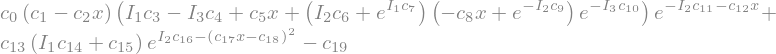


Latex version:
c_{0} \left(c_{1} - c_{2} x\right) \left(I_{1} c_{3} - I_{3} c_{4} + c_{5} x + \left(I_{2} c_{6} + e^{I_{1} c_{7}}\right) \left(- c_{8} x + e^{- I_{2} c_{9}}\right) e^{- I_{3} c_{10}}\right) e^{- I_{2} c_{11} - c_{12} x} + c_{13} \left(I_{1} c_{14} + c_{15}\right) e^{I_{2} c_{16} - \left(c_{17} x - c_{18}\right)^{2}} - c_{19}

Value at x=1:


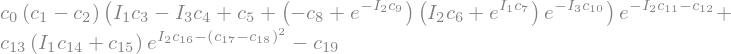


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 23
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2', 'IOB3']
Final number of parameters: 15
Of which global: 9 and local: 6
Final values: [-0.00246600000000000, -9.12580800000000, 45.120201, 1.380509, -6.73094700000000, 16.786709, 1.000648, -208.741272000000, -3.95305900000000]
Local replacements: {B0: c13*(IOB1*c14 + c15), B1: IOB2*c16, B2: IOB1*c3 - IOB3*c4, B3: (IOB2*c6 + exp(IOB1*c7))*exp(-IOB3*c10), B4: -IOB2*c9, B5: -IOB2*c11}



Latex version:
B_{0} e^{B_{1} - \left(a_{4} + a_{5} x\right)^{2}} + a_{0} + a_{6} \left(a_{2} + a_{7} x\right) \left(B_{2} + B_{3} \left(a_{8} x + e^{B_{4}}\right) + a_{3} x\right) e^{B_{5} + a_{1} x}

Value at x=1:


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini

Target: A

RMSE train: 2.436e-01
		1 sigma: -0.23175172463876467 0.10447875809517146
		RMSE: 0.11566905255581407
		RMAE: 0.05463880133837153
		1 sigma: -0.09864719252444493 0.07103099935843599
Median absolute DF/F 0.011033456291221322
RMSE DF/F 0.04992252401613145

RMSE val: 2.429e-01
		1 sigma: -0.23326654812283754 0.10679967008603697
		RMSE: 0.11698166368368018
		RMAE: 0.0569376119045881
		1 sigma: -0.0956743490679334 0.06909560511233441
Median absolute DF/F 0.010626169214092762
RMSE DF/F 0.047374432528037365

Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini

Target: A


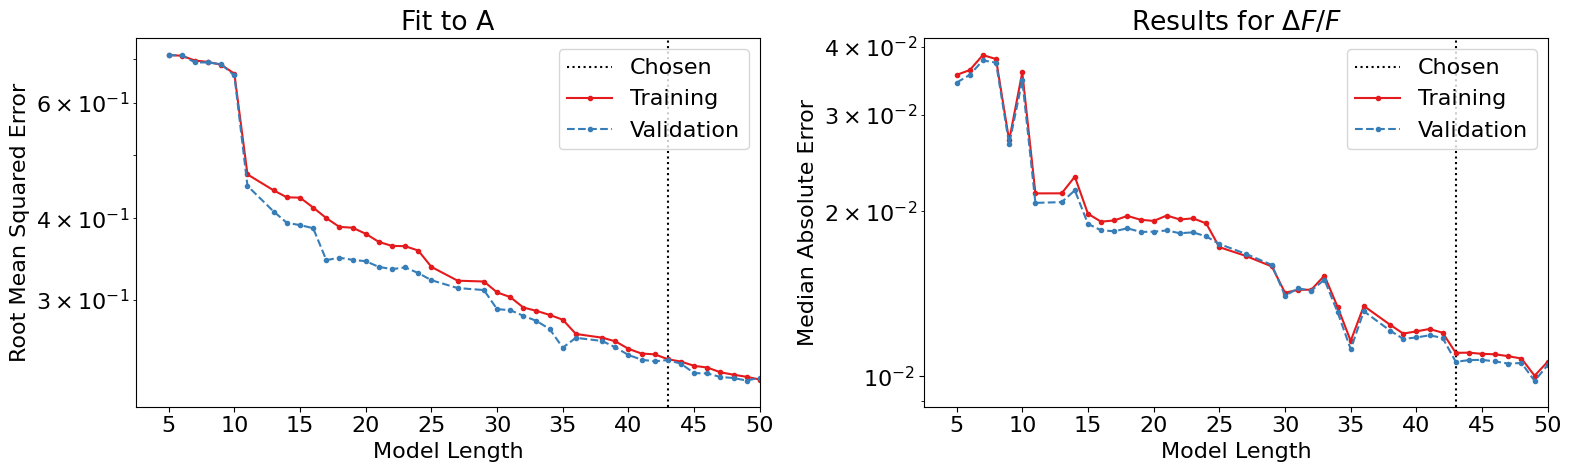

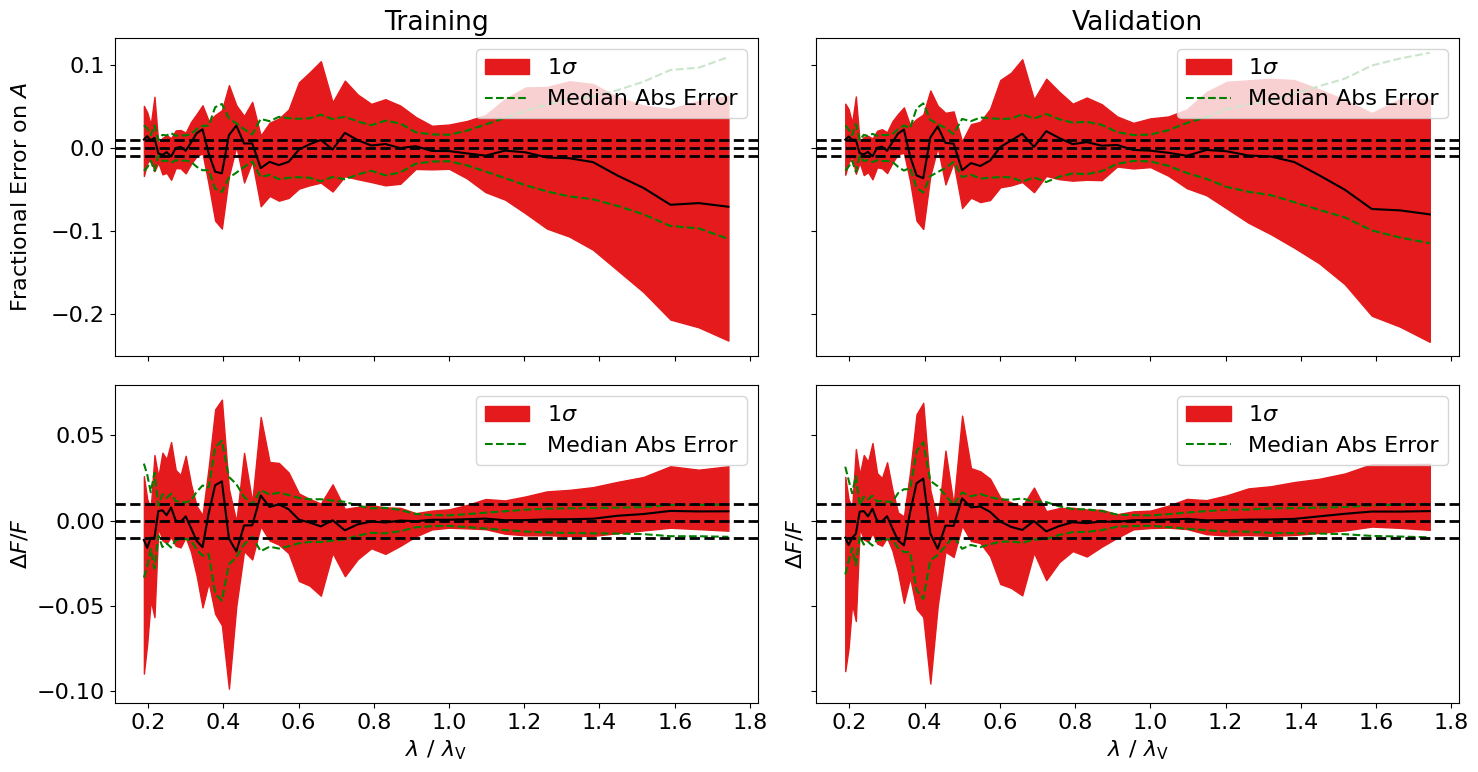

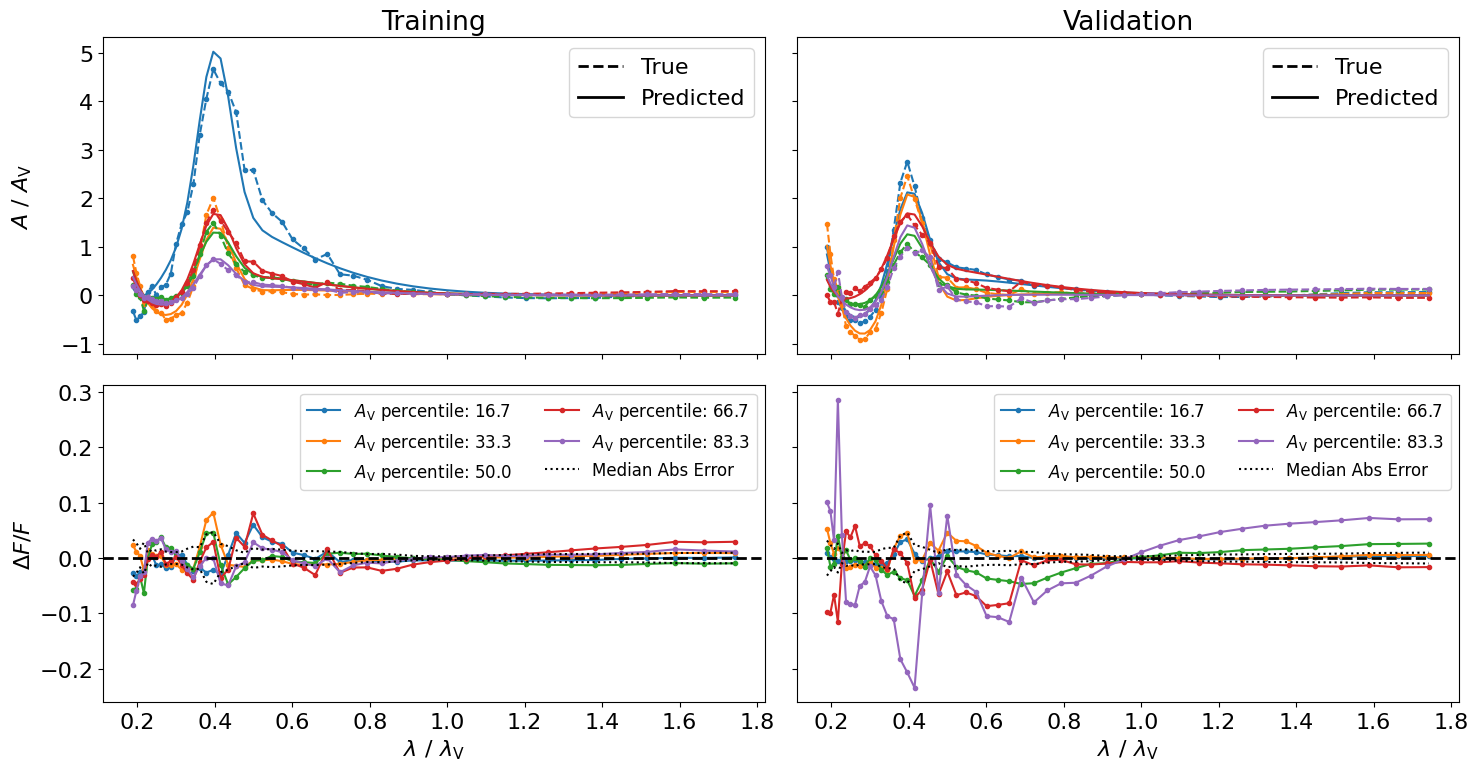

In [25]:
ini_file = 'conf/iob_0.ini'; ilen = None
ini_file = 'conf/iob_1.ini'; ilen = None
ini_file = 'conf/iob_2.ini'; ilen = None
ini_file = 'conf/iob_3.ini'; ilen = None
ini_file = 'conf/iob_4.ini'; ilen = None
# ini_file = 'conf/iob_5.ini'; ilen = None
# ini_file = 'conf/iob_6.ini'; ilen = None
# ini_file = 'conf/iob_7.ini'; ilen = 40
# ini_file = 'conf/iob_8.ini'; ilen = 29
ini_file = 'conf/iob_9.ini'; ilen = 32; ilen = 13 # No bump

# ini_file = 'conf/iob_10.ini'; ilen = None; ilen = 28 # No bump - remove exp from basis
# ilen = 15

# ini_file = 'conf/iob_11.ini'; ilen = None # Full curve, 24hr
# ini_file = 'conf/iob_12.ini'; ilen = 48 # Full curve, 24hr, add aq to basis
# ini_file = 'conf/iob_13.ini'; ilen = None # Full curve, 48hr
# ini_file = 'conf/iob_14.ini'; ilen = None # Full curve, 48hr, add aq to basis

# ini_file = 'conf/iob_15.ini'; ilen = None; ilen=56  # Full curve, 24hr, linear space
# NOTE: ilen=56 looks like denominator could have a zero, but the minimum of this is
# ~0.0294 at x=0.38 for any x, so it's fine.
# ilen=56 is my favourite up to run 16. Need to check overall minimum etc.
# Problem as x -> inf? Looks like it goes to 1, but wanted 0?
# ilen = 41

# ini_file = 'conf/iob_16.ini'; ilen = None # Full curve, 24hr, add aq to basis, linear space

ini_file = 'conf/iob_17.ini'; ilen = 64 # Full curve, 48hr, linear space
# ini_file = 'conf/iob_18.ini'; ilen = 40 # Full curve, 48hr, linear space

# ini_file = 'conf/iob_19.ini'; ilen = 74
# ini_file = 'conf/iob_20.ini'; ilen = 45
# ini_file = 'conf/iob_21.ini'; ilen = 63

# ini_file = 'conf/iob_22.ini'; ilen = None  # No bump but MSE error

# No bump and short max model length
# ini_file = 'conf/iob_23.ini'; ilen = None
# ini_file = 'conf/iob_24.ini'; ilen = 13
# ini_file = 'conf/iob_25.ini'; ilen = 13
# ini_file = 'conf/iob_26.ini'; ilen = 13
# # ini_file = 'conf/iob_27.ini'; ilen = 14
# ini_file = 'conf/iob_28.ini'; ilen = 19
# ini_file = 'conf/iob_29.ini'; ilen = 15
# # ini_file = 'conf/iob_30.ini'; ilen = 14
# # ilen = 15
ini_file = 'conf/iob_31.ini'; ilen = 15
# run 32 failed (node error)
ini_file = 'conf/iob_35.ini'; ilen = 13  # THIS IS WHAT IS CHOSEN FOR THE OUTER FUNCTION

# Back to full curve fits with MSE
# ini_file = 'conf/iob_33.ini'; ilen = 65;
# ini_file = 'conf/iob_34.ini'; ilen = 65

# Full curve where we subtract outer first
# ini_file = 'conf/iob_36.ini'; ilen = 35; ilen = 26
# ini_file = 'conf/iob_37.ini'; ilen = 34
# ini_file = 'conf/iob_38.ini'; ilen = None
# ini_file = 'conf/iob_39.ini'; ilen = 36
ini_file = 'conf/iob_40.ini'; ilen = 41; ilen = 34 # NOT BAD
# ini_file = 'conf/iob_41.ini'; ilen = 36
# ini_file = 'conf/iob_42.ini'; ilen = 38
# ini_file = 'conf/iob_43.ini'; ilen = None
ini_file = 'conf/iob_44.ini'; ilen = 43
# ini_file = 'conf/iob_45.ini'; ilen = 43
# ini_file = 'conf/iob_46.ini'; ilen = 29

args = OperonArgs(ini_file, verbose=False)
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=True);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=5, plot_av_diff=False, plot_dF_F=True, yscale='linear', subtract_outer=args.subtract_outer);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini

Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003
(1473, 8)
1070
-0.07853446728300001 0.243605792742 0.004746363423809912


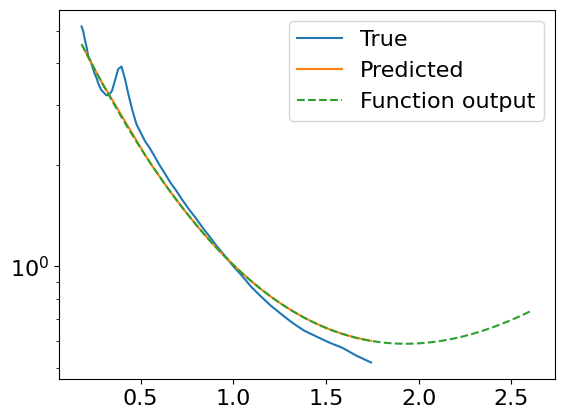

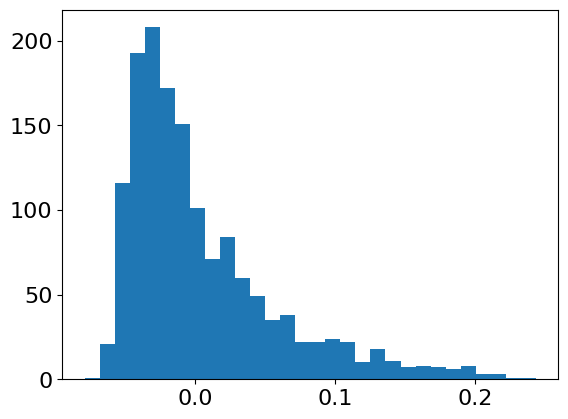

In [45]:
name = 'train'
# ini_file = 'conf/iob_6.ini'; ilen = 32
# ini_file = 'conf/iob_29.ini'; ilen = 15
# ini_file = 'conf/iob_30.ini'; ilen = 14

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
data_train = pd.read_csv(fname)
iob_cols = sorted([col for col in data_train.columns if re.match(r'IOB\d+', col)])
lam_cols = [col for col in data_train.columns if re.match(r'A_\d+', col)]
ytrue = data_train[lam_cols].values
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
A_v = data_train[A_v_col].values
lam = np.array([int(re.search(r'_(\d+)', col).group(1)) / 1e4 for col in lam_cols])
x = lam / args.lambda_V

# Get AV
attenuation_cols = [col for col in data_train.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data for prediction
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ypred = data[:,args.npar+2]
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname = pjoin(dirname, f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
x_sub = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(x_sub))

importlib.reload(sr_fun)
xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)

for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = sr_fun.compute_Av(xplot, *B)
    # new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()

#     print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
#     print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

plt.yscale('log')

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values

IOB = data_train[iob_cols].values
print(IOB.shape)
B = sr_fun.compute_initial_B(IOB.T)
print(np.argmax(B))
plt.figure()
plt.hist(B, bins=30)
print(np.min(B), np.max(B), np.mean(B))



Fitted tanh parameters: A=2.262279396227433, B=0.7592281966296044, C=1.2482650712040162
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003


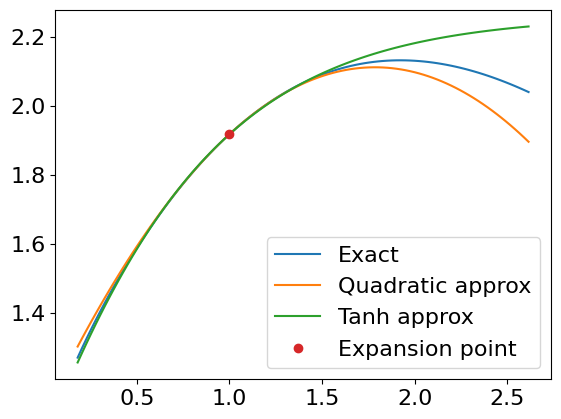

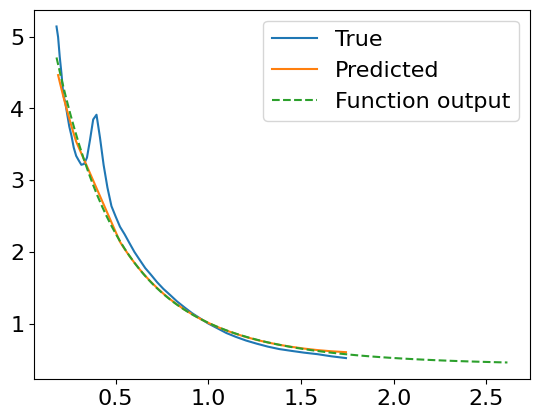

In [61]:
# i = 10
# xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)
# IOB = data_train[iob_cols].values[i]
# print(f"IOB values: {IOB}")
# B = sr_fun.compute_initial_B(IOB)
# a = [-0.0123170000000000, -0.481067000000000, 1.015321, 4.279083, -2.19217600000000, 0.198605]
# # A_over_Av = a[0] + a[2]*(B0 - (a[3]*xplot)**B1)*(a[4] + (a[5]*xplot)**(a[1]*xplot))
# plt.axhline(a[4])
# plt.plot(xplot, (a[5]*xplot)**(a[1]*xplot))

a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]

# Quadratic approximation
a_val = a[6]
b = a[1]

a0 = a_val ** b
a1 = b * (np.log(a_val) + 1) * a_val ** b
a2 = b * a_val ** b * (1 + b * (np.log(a_val) + 1)**2)
h  = xplot - 1

def approx_fun(x, A, B, C):
    return A * np.tanh(B * (x - 1) + C)

# Get approximation as a tanh function
xfit = np.linspace(0.5, 1.5, 50)
y = (a_val*xfit)**(b*xfit)
res = scipy.optimize.curve_fit(approx_fun, xfit, y, p0=[a0, 2., 0])
A_fit, B_fit, C_fit = res[0]
print(f'Fitted tanh parameters: A={A_fit}, B={B_fit}, C={C_fit}')
y_tanh = approx_fun(xplot, A_fit, B_fit, C_fit)

plt.plot(xplot, (a_val*xplot)**(b*xplot), label='Exact')
plt.plot(xplot, a0 + a1*h + 0.5*a2*h**2, label='Quadratic approx')
plt.plot(xplot, y_tanh, label='Tanh approx')
plt.plot([1.], [a0], 'o', label='Expansion point')
plt.legend()

def compute_Av(x, B0):
    a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]
    # A_over_Av = a[0] + a[2]*(a[3] + (a[6]*x)**(a[1]*x))*(a[4] + (a[5]*x)**B0)
    A_over_Av = a[0] + a[2]*(a[3] + approx_fun(x, A_fit, B_fit, C_fit))*(a[4] + (a[5]*x)**B0)
    return A_over_Av

plt.figure()
for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()


# Optimise outer term

Now we have a functional form for the outer term, we manipulate the function and try to re-optimise its parameters


Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini
(54501, 8) (54501,)

Initial b parameters: [0.9753444117120513, 0.944124]
Training loss with initial b: 0.09391890558372663
Validation loss with initial b: 0.08960616006489754

True, Optimization terminated successfully.

Optimised b parameters: [1.00793398 0.97752676]
Training loss with optimised b: 0.07165507154363666
Validation loss with optimised b: 0.06751158381571837


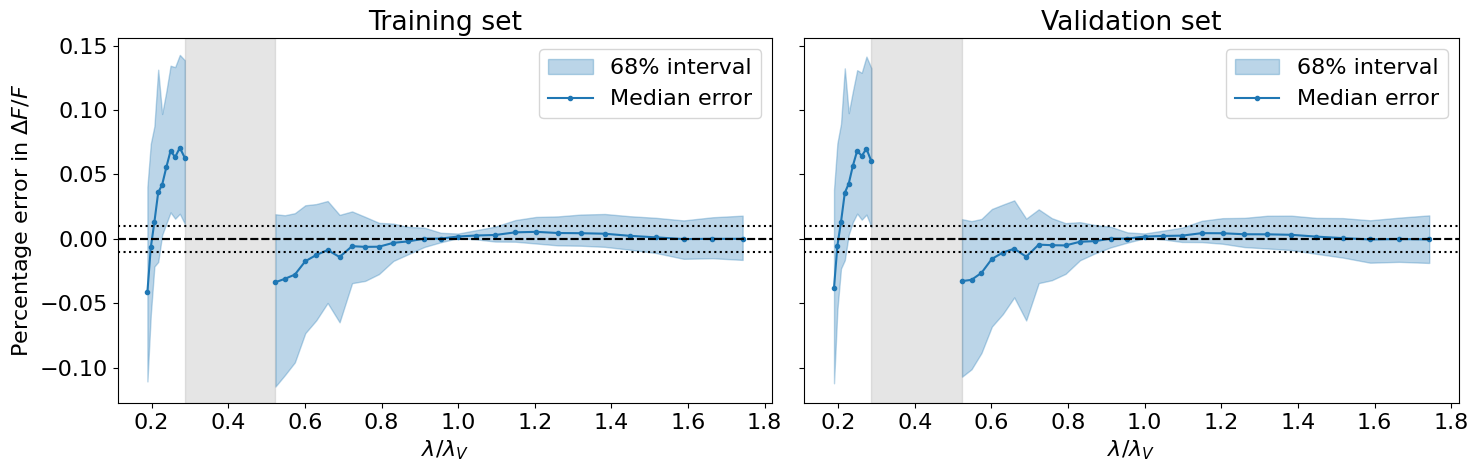

In [51]:
def compute_initial_C(IOB):
    c = [0.908373, 0.748169, 0.944124, 59.20784, 5.327414, 0.010842]
    B0 = c[0]*np.log(IOB[0]*c[3] + c[4])
    C0 = B0 * np.log(10)
    return C0

def compute_Av(x, b, C0):
    A_over_Av = b[0] * np.exp(C0*(np.tanh(b[1]) - np.tanh(b[1]*x)))
    return A_over_Av

def loss_fun_b(b, x, A_true, A_v, C0):
    A_pred = compute_Av(x, b, C0)
    # loss = np.sqrt(np.mean((np.log(ypred) - np.log(ytrue))**2))
    dF_F_train = 10. ** (0.4 * A_v * (A_true - A_pred)) - 1.0
    loss = np.sqrt(np.mean(dF_F_train**2))
    return loss

b_init = [10 ** (-0.0108420000000000), 0.944124]

args = OperonArgs(ini_file)

# Load training and validation data
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')
df_train = pd.read_csv(fname_train, sep=r'\s+')
df_val = pd.read_csv(fname_val, sep=r'\s+')

# Get the normalisation of the curves
df_all_train = pd.read_csv(args.selection.train_file)
df_all_val = pd.read_csv(args.selection.val_file)
log_Av_col = f'logA_{int(args.lambda_V*1e4)}A'
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
if log_Av_col in df_all_train.columns:
    lv_key = log_Av_col
elif A_v_col in df_all_train.columns:
    lv_key = A_v_col
else:
    raise ValueError("Column with lambda_V not found in input file")

# Get A_v for training and validation sets so we can calculate dF/F after fitting
train_id = df_train['galaxy_id'].values
train_los = df_train['los'].values
val_id = df_val['galaxy_id'].values
val_los = df_val['los'].values
m = df_all_train.set_index(['galaxy_id', 'los'])
train_Av = m.loc[list(zip(train_id, train_los)), lv_key].values
m = df_all_val.set_index(['galaxy_id', 'los'])
val_Av = m.loc[list(zip(val_id, val_los)), lv_key].values

print(df_train.shape, train_Av.shape)

# Extract IOB values and variables we care about
IOB_cols = sorted([col for col in df_train.columns if re.match(r'IOB\d+', col)])
IOB_train = df_train[IOB_cols].values
IOB_val = df_val[IOB_cols].values
x_train = df_train['lam'].values
x_val = df_val['lam'].values

# Get C0 for training and validation sets
C0_train = compute_initial_C(IOB_train.T)
C0_val = compute_initial_C(IOB_val.T)

A_train = df_train['A'].values
A_val = df_val['A'].values

print(f'\nInitial b parameters: {b_init}')
print(f'Training loss with initial b: {loss_fun_b(b_init, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with initial b: {loss_fun_b(b_init, x_val, A_val, val_Av, C0_val)}')

# Optimise b parameters
res = scipy.optimize.minimize(loss_fun_b, b_init, args=(x_train, A_train, train_Av, C0_train), method='Nelder-Mead')
print(f'\n{res.success}, {res.message}\n')
b_opt = res.x

print(f'Optimised b parameters: {b_opt}')
print(f'Training loss with optimised b: {loss_fun_b(b_opt, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with optimised b: {loss_fun_b(b_opt, x_val, A_val, val_Av, C0_val)}')

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)

mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

After fixing the $b$ parameters, we re-optimised the C0. Compare the losses for each gal and the values of C0

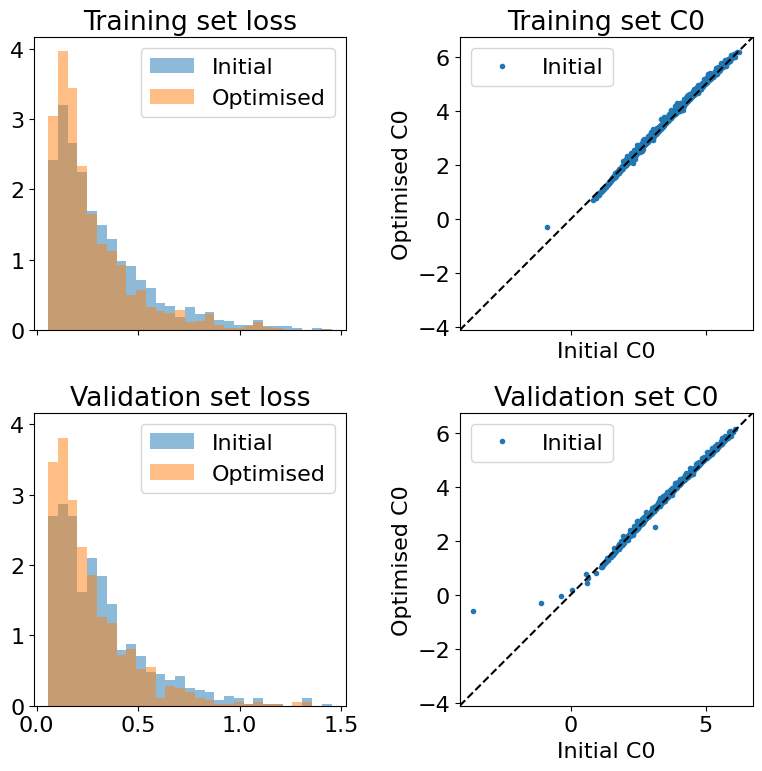

In [71]:
fname_train = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_train.csv'
df_results_train = pd.read_csv(fname_train)
fname_val = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_val.csv'
df_results_val = pd.read_csv(fname_val)

fig, axs = plt.subplots(2, 2, figsize=(8,8), sharey='col', sharex='col')

bins = np.linspace(np.percentile(df_results_train['loss_init'], 0.5), np.percentile(df_results_train['loss_init'], 99.5), 30)
axs[0,0].hist(df_results_train['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[0,0].hist(df_results_train['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')
axs[1,0].hist(df_results_val['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[1,0].hist(df_results_val['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')

axs[0,1].plot(df_results_train['C0_init'], df_results_train['C0_opt'], '.', label='Initial')
axs[1,1].plot(df_results_val['C0_init'], df_results_val['C0_opt'], '.', label='Initial')
for ax in axs[:,1]:
    ax.set_xlabel('Initial C0')
    ax.set_ylabel('Optimised C0')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xlim = (min(xlim[0], ylim[0]), max(xlim[1], ylim[1]))
    ylim = xlim
    ax.plot(xlim, ylim, 'k--')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', 'box')
for ax in axs.flatten():
    ax.legend()
axs[0,0].set_title('Training set loss')
axs[1,0].set_title('Validation set loss')
axs[0,1].set_title('Training set C0')
axs[1,1].set_title('Validation set C0')
fig.tight_layout()

Now see how this looks in terms of the attenuation curve

(54501,) (27232,)


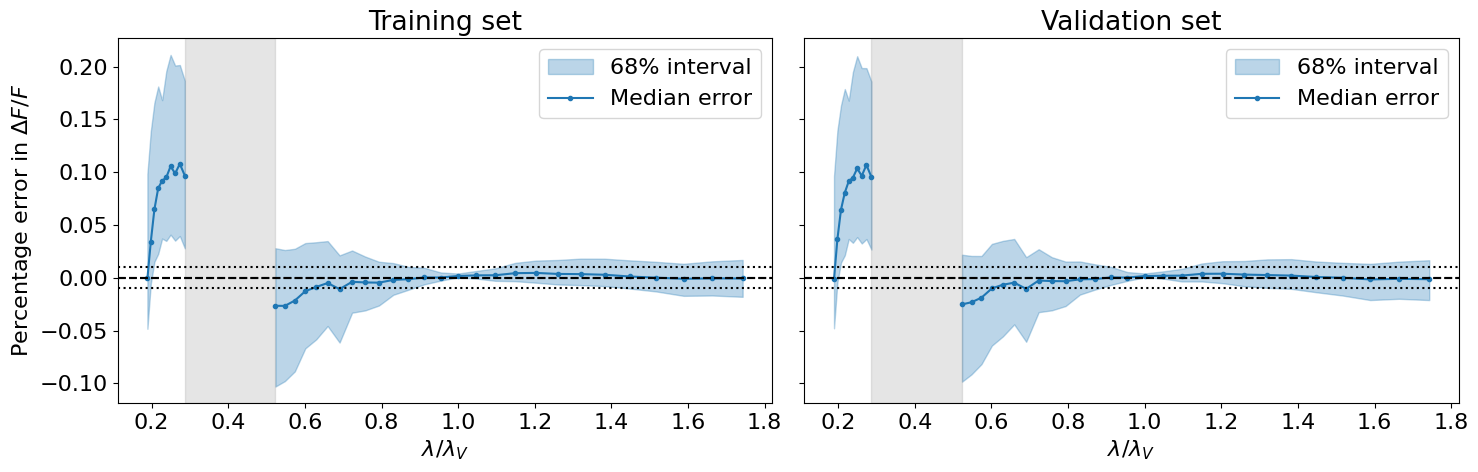

In [80]:
C0_train = df_results_train['C0_opt'].values
C0_val = df_results_val['C0_opt'].values

# Repeat this value so that this has the same shape as our training data
C0_train_full = np.repeat(C0_train, len(x_uniq))
C0_val_full = np.repeat(C0_val, len(x_uniq))
print(C0_train_full.shape, C0_val_full.shape)

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train_full[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val_full[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)
    
mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

# Investigate terms in the "inner" function


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
['IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6', 'IOB7', 'IOB8']
x1: 0.21615371300410585
x2 min: 0.005524093602188656, x2 max: 8.341591184543697
Number of positive x2: 1454, number of negative x2: 19
Fraction positive: 0.9871
Fraction negative: 0.0129
Number of 0.1 < x2 < 1.0: 1432
Fraction 0.1 < x2 < 1.0: 0.9722
Number of positive D1: 1364, number of negative D1: 109
Fraction positive: 0.9260
Fraction negative: 0.0740
b2 45.149438890248


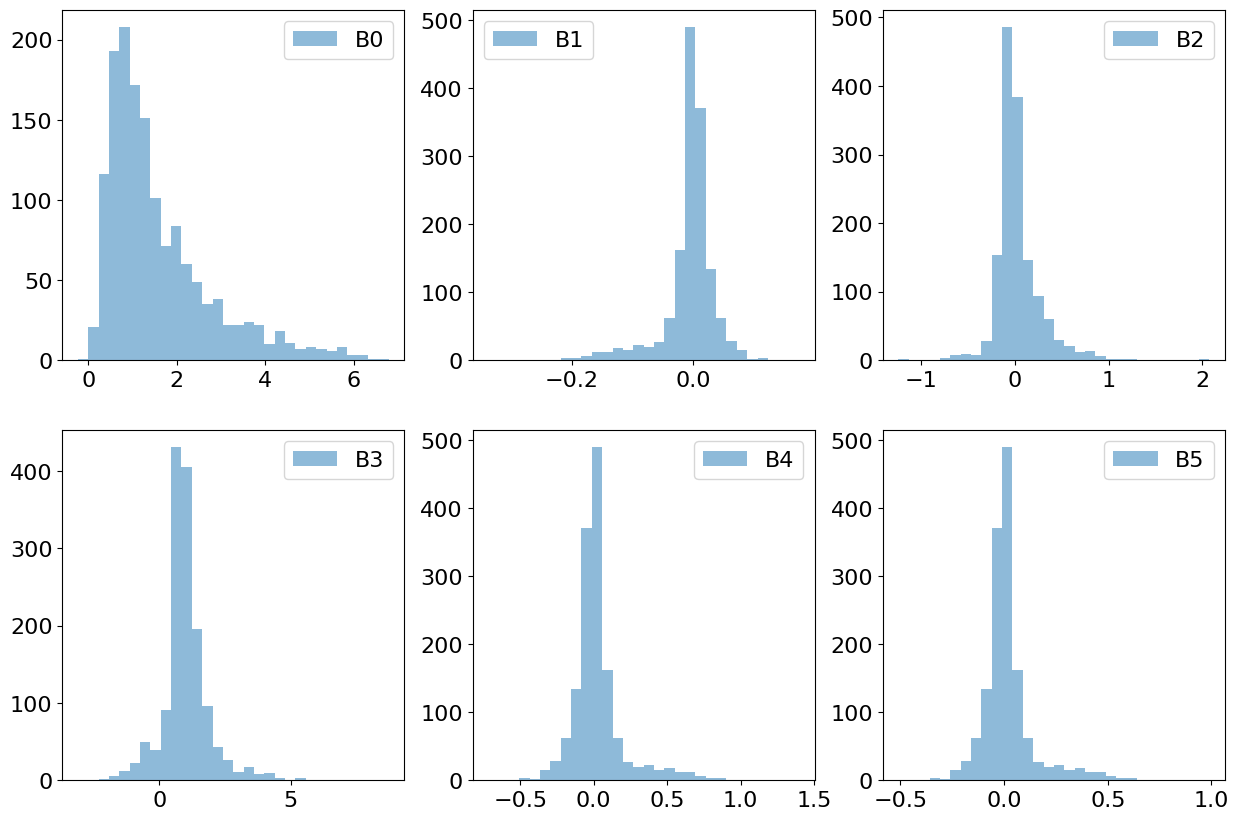

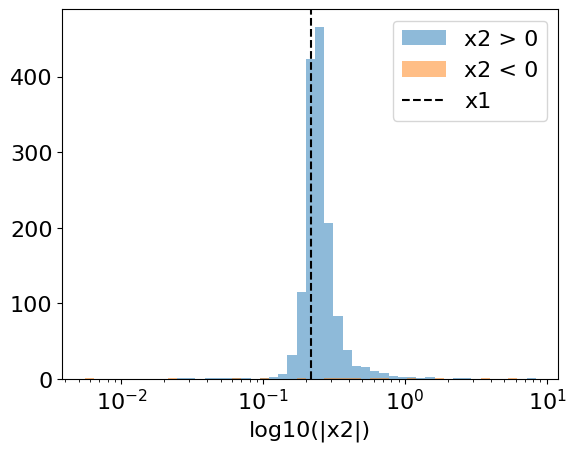

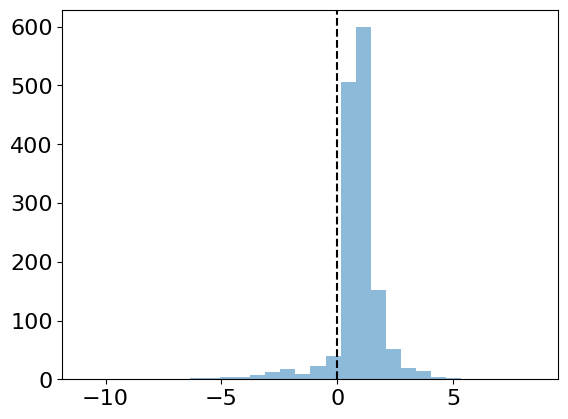

In [43]:
name = 'train'
ini_file = 'conf/iob_44.ini'; ilen = 43

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
data_train = pd.read_csv(fname)
iob_cols = sorted([col for col in data_train.columns if re.match(r'IOB\d+', col)])

c = [1.000648, 45.120201, 208.741272, 2.214609, 11.210193, 1.380509, 22.421267, 5.736165, 3.953059, 5.040799, 7.073277, 3.570695, 9.125808, 1.000648, 21.685377, 1.474194, 1.215716, 16.786709, 6.730947, 0.002466]

print(iob_cols)
# {B0: c13*(IOB1*c14 + c15), B1: IOB2*c16, B2: IOB1*c3 - IOB3*c4, B3: (IOB2*c6 + exp(IOB1*c7))*exp(-IOB3*c10), B4: -IOB2*c9, B5: -IOB2*c11}
B0 = c[13] * (data_train['IOB1'].values * c[14] + c[15])
B1 = data_train['IOB2'].values * c[16]
B2 = c[3] * data_train['IOB1'].values - c[4] * data_train['IOB3'].values
B3 = (c[6] * data_train['IOB2'].values + np.exp(c[7] * data_train['IOB1'].values)) * np.exp(-c[10] * data_train['IOB3'].values)
B4 = -c[9] * data_train['IOB2'].values
B5 = -c[11] * data_train['IOB2'].values

fig, axs = plt.subplots(2, 3, figsize=(15,10))
axs[0,0].hist(B0, bins=30, alpha=0.5, label='B0')
axs[0,1].hist(B1, bins=30, alpha=0.5, label='B1')
axs[0,2].hist(B2, bins=30, alpha=0.5, label='B2')
axs[1,0].hist(B3, bins=30, alpha=0.5, label='B3')
axs[1,1].hist(B4, bins=30, alpha=0.5, label='B4')
axs[1,2].hist(B5, bins=30, alpha=0.5, label='B5')
for ax in axs.flatten():
    ax.legend()

a = [-0.00246600000000000, -9.12580800000000, 45.120201, 1.380509, -6.73094700000000, 16.786709, 1.000648, -208.741272000000, -3.95305900000000]

x1 = - a[2] / a[7]
print(f'x1: {x1}')

x2 = - 1/a[8] * (np.exp(B4) + B2 / B3)
xmin = np.min(np.abs(x2))
xmax = np.max(np.abs(x2))
bins = np.logspace(np.log10(xmin), np.log10(xmax), 50)
print(f'x2 min: {xmin}, x2 max: {xmax}')
plt.figure()
plt.hist(x2[x2>0], bins=bins, alpha=0.5, label='x2 > 0')
plt.hist(-x2[x2<0], bins=bins, alpha=0.5, label='x2 < 0')
plt.axvline(x1, color='k', ls='--', label='x1')
plt.xscale('log')
plt.xlabel('log10(|x2|)')
plt.legend()

npos = np.sum(x2 > 0)
nneg = np.sum(x2 < 0)
print(f'Number of positive x2: {npos}, number of negative x2: {nneg}')
print(f'Fraction positive: {npos / (npos + nneg):.4f}')
print(f'Fraction negative: {nneg / (npos + nneg):.4f}')

m = (x2 > 0.1) & (x2 < 1.0)
print(f'Number of 0.1 < x2 < 1.0: {np.sum(m)}')
print(f'Fraction 0.1 < x2 < 1.0: {np.sum(m) / (npos + nneg):.4f}')

D1 = np.exp(B5) * (B2 + B3 * np.exp(B4))
npos = np.sum(D1 > 0)
nneg = np.sum(D1 < 0)
print(f'Number of positive D1: {npos}, number of negative D1: {nneg}')
print(f'Fraction positive: {npos / (npos + nneg):.4f}')
print(f'Fraction negative: {nneg / (npos + nneg):.4f}')
plt.figure()
plt.hist(D1, bins=30, alpha=0.5)
plt.axvline(0., color='k', ls='--')

print('b2', a[2] * a[6])


# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


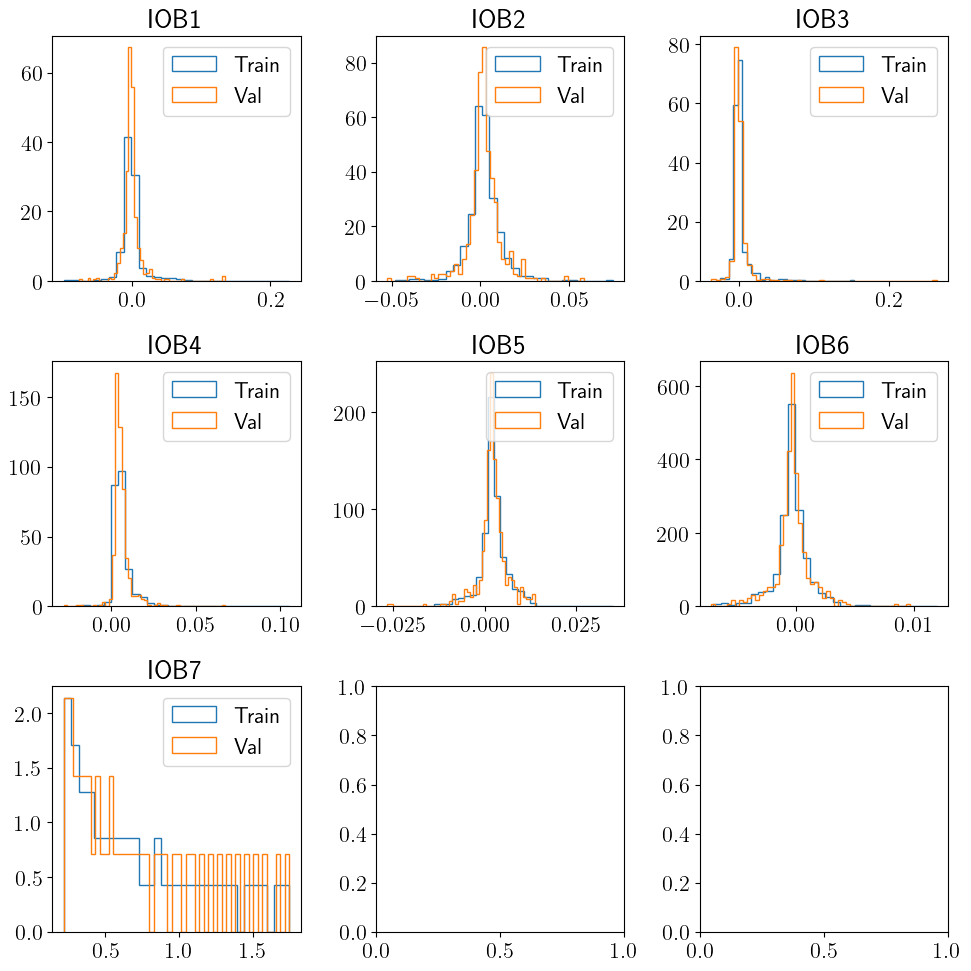

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()

# Look at distribution of IOB parameter combinations


Reading from configuration file: conf/iob_6.ini

Reading from configuration file: conf/selection_0.ini
-5369.777802441621 138992.38562712393 533.9560958773085 5.14299100909797


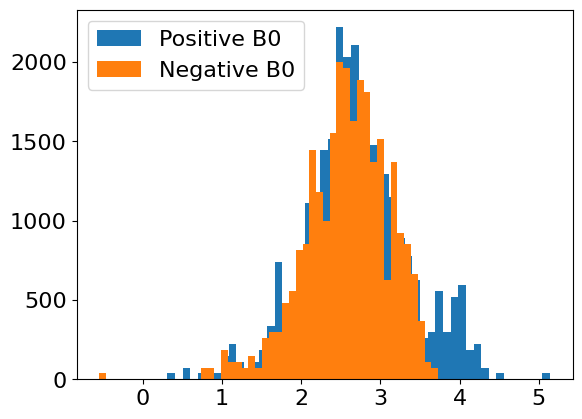

In [18]:
ini_file = 'conf/iob_6.ini';
args = OperonArgs(ini_file)
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
data = pd.read_csv(fname_train, sep=r'\s+')

c = [0.999999, 5.160664, 14.21899, 96.767336287521, 346.455505, 418.237518, 308.280884, 64.732704, 69744.210938, 20.115023, 0.989066010925, 0.999999, 2.638054, 7.050597, 91.976021, 4.946947, 0.441919, 0.045192, 1391.598999, 182.675049, 3.984417, 7.549686, 0.985602, 6.911434, 2.567828]
IOB1 = data['IOB1'].values
IOB2 = data['IOB2'].values
IOB3 = data['IOB3'].values
B0 = -c[0]*(-IOB2**2*c[3]*(-IOB1*c[4] - IOB2*c[5] - IOB3*c[6] + c[7])**2 - IOB3*c[8])

print(B0.min(), B0.max(), B0.mean(), np.log10(np.abs(B0)).max())

m = B0 > 0
plt.hist(np.log10(B0[m]), bins=50, label='Positive B0')
plt.hist(np.log10(-B0[~m]), bins=50, label='Negative B0')
plt.legend()

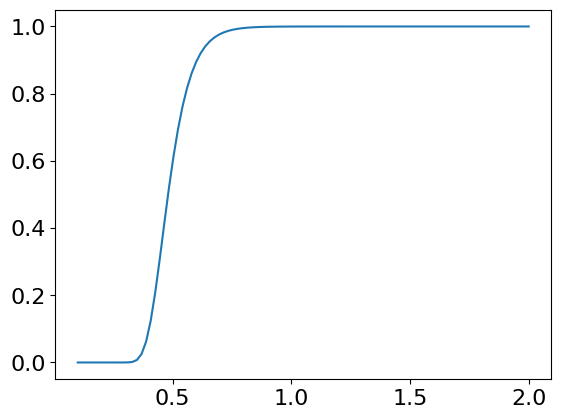

In [31]:
x = np.linspace(0.1, 2, 100)
a8 = -5908.80419900000
a10 = -17.3103690000000
y = np.exp(a8 * x * np.exp(a10 * x))
plt.plot(x, y)